# 02. DNN 실전의 함정 - 모델은 언제, 왜 틀리는가

노트북 01에서 MNIST/Fashion-MNIST/LFW로 DNN을 학습시켰고, 검증 정확도도 그럴듯했다.
하지만 **깔끔한 데이터셋에서 잘 되는 것과, 실전에서 잘 되는 것은 다르다.**

이 노트북은 두 가지 실패를 일부러 재현한다.

1. **극성(polarity) 버그** - 직접 그린 숫자 `6`을 학습된 MNIST 모델에 넣었더니, **확률 1.0으로 확신하며 틀린 답**을 내놓는다. 왜일까?
2. **과소 데이터** - 사진 12장으로 1,000만 파라미터 모델을 학습시키면 무슨 일이 벌어지는가?

두 사례 모두 "정확도가 높았는데 왜 실전에서 무너지는가"를 보여준다.

## 준비 - Google Drive 연결

이 노트북은 손글씨 이미지(`6.png`)와 얼굴 사진이 필요하다. Drive에 올려두고 마운트한다.

> **경로는 각자 환경에 맞게 `root`를 수정할 것.** 아래는 `MyDrive/Colab Notebooks/` 기준이다.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

import os
root = "/content/gdrive/MyDrive/Colab Notebooks/"
assert os.path.exists(root), f"경로 없음: {root}"

Mounted at /content/gdrive


## 1부. 극성 버그 - 확률 1.0으로 확신하며 틀리기

### 1-1. MNIST 모델 학습

먼저 노트북 01에서 만든 것과 같은 DNN을 MNIST로 학습한다.
`restore_best_weights=True`가 붙은 EarlyStopping도 그대로 쓴다.

```
Input(784) → Dense(256, relu) → Dense(64, relu) → Dense(10, softmax)
```

In [2]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train_1d = x_train.reshape(len(x_train), -1) / 255
x_test_1d = x_test.reshape(len(x_test), -1) / 255
y_train_oh = to_categorical(y_train)
y_test_oh = to_categorical(y_test)

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

esc = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(x_train_1d, y_train_oh,
          validation_data=(x_test_1d, y_test_oh),
          epochs=50, callbacks=[esc])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9368 - loss: 0.2149 - val_accuracy: 0.9670 - val_loss: 0.1103
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9735 - loss: 0.0873 - val_accuracy: 0.9736 - val_loss: 0.0829
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9807 - loss: 0.0609 - val_accuracy: 0.9763 - val_loss: 0.0796
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9853 - loss: 0.0470 - val_accuracy: 0.9758 - val_loss: 0.0803
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 0.9792 - val_loss: 0.0728
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9910 - loss: 0.0273 - val_accuracy: 0.9803 - val_loss: 0.0765
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9917 - loss: 0.0261 - val_accuracy: 0.9765 - val_loss: 0.0901
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━

### 1-2. 학습 데이터가 어떻게 생겼는지 다시 보기

버그를 이해하려면 **모델이 무엇을 보고 배웠는지** 알아야 한다.
MNIST 이미지 하나의 픽셀 분포를 확인한다.

MNIST 한 장 - min: 0 max: 255 평균: 35.1
네 모서리(배경): 0 0 0 0


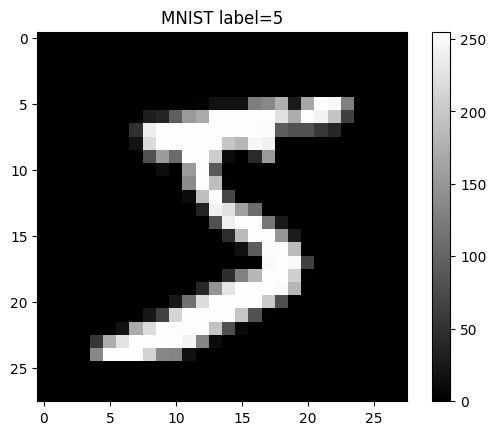

In [3]:
import matplotlib.pyplot as plt

sample = x_train[0]
print("MNIST 한 장 - min:", sample.min(), "max:", sample.max(), "평균:", sample.mean().round(1))
print("네 모서리(배경):", sample[0,0], sample[0,-1], sample[-1,0], sample[-1, -1])

plt.imshow(sample, cmap='gray')
plt.title(f"MNIST label={y_train[0]}")
plt.colorbar()
plt.show()

### 1-3 손글씨 `6`을 넣어보기 - 원본 그대로

이제 손으로 그린 `6.png`(28x28)를 모델에 넣는다.
그림판이나 일반적인 방법으로 그리면 **흰 종이에 검은 펜** - 즉 배경이 밝다.

원본 수업 코드처럼 아무 처리 없이 `/255`만 해서 넣어본다.

6.png - min: 0 max: 255 평균: 188.6
네 모서리(배경): 255 255 255 255


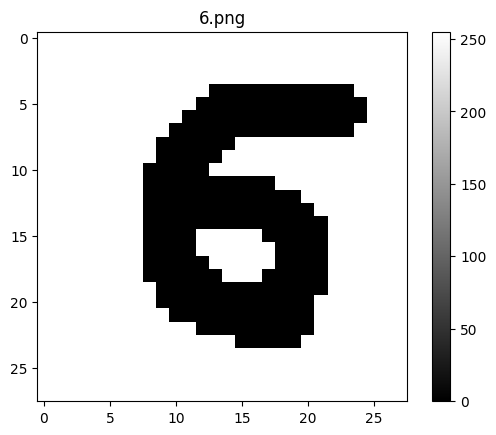

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step

예측: 5 | 확률: 0.58479
전체 확률 분포: [0.     0.     0.4152 0.     0.     0.5848 0.     0.     0.     0.    ]


In [4]:
from PIL import Image

img = Image.open(os.path.join(root, "6.png")).convert('L')
ndimg = np.array(img)
print("6.png - min:", ndimg.min(), "max:", ndimg.max(), "평균:", ndimg.mean().round(1))
print("네 모서리(배경):", ndimg[0,0], ndimg[0,-1], ndimg[-1,0], ndimg[-1,-1])

plt.imshow(ndimg, cmap='gray')
plt.title("6.png")
plt.colorbar()
plt.show()

# 원본 그대로: 그냥 펼치고 255로 나눈다
x_myimg = ndimg.reshape(1, -1) / 255
pred = model.predict(x_myimg)
print("\n예측:", np.argmax(pred[0]), "| 확률:", pred[0].max().round(6))
print("전체 확률 분포:", pred[0].round(4))

### 1-4. 무슨 일이 일어났는가 ★

모델은 **틀린 답을, 그것도 확률 1.0에 가깝게 확신하며** 내놓는다.

이유는 극성(밝고 어두움)이 뒤집혔기 때문이다:
- **MNIST**: 배경 = 0(검정), 획 = 1(흼). 모델은 "대부분 0이고 일부만 1인 그림"을 숫자로 배웠다.
- **내 그림**: 배경 = 1(흼), 획 = 0(검정). **모델 입장에선 화면이 거의 다 켜져 있는(1) 처음 보는 패턴이다.**

모델은 이런 입력을 학습한 적이 없다. 그런데도 softmax는 **반드시 합이 1인 확률을 뱉어야** 하므로,
가장 그럴싸한 클래스 하나에 확률을 몰아준다. 그 결과가 "1.0으로 확신하는 오답"이다.

> **교훈 1: softmax 확률은 신뢰도가 아니다.** 1.0이 찍혀도 틀릴 수 있다.
> **교훈 2: 추론 데이터는 학습 데이터와 같은 형태(분포)여야 한다.** 스케일, 극성, 크기 전부.


### 1-5. 극성을 맞춰주기 — `1 - x`

고치는 법은 간단하다. 밝기를 뒤집어서 MNIST와 같은 극성으로 만든다.

`1 - (x / 255)` → 흰 배경(1)은 0으로, 검은 획(0)은 1로. 이제 검은 배경에 흰 글씨가 된다.


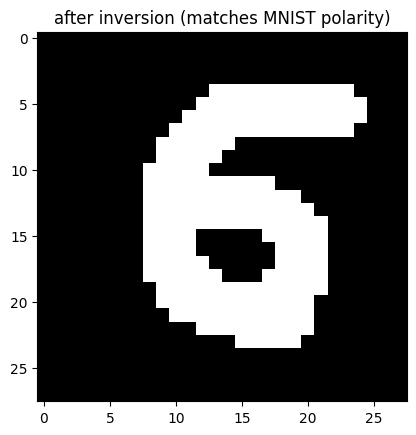

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
예측: 5 | 확률: 0.999275
전체 확률 분포: [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 9.993e-01 7.000e-04
 0.000e+00 0.000e+00 0.000e+00]


In [5]:
x_fixed = 1 - (ndimg.reshape(1, -1) / 255)   # 극성 반전

plt.imshow(x_fixed.reshape(28, 28), cmap='gray')
plt.title("after inversion (matches MNIST polarity)")
plt.show()

pred = model.predict(x_fixed)
print("예측:", np.argmax(pred[0]), "| 확률:", pred[0].max().round(6))
print("전체 확률 분포:", pred[0].round(4))


---
## 2부. 과소 데이터의 함정 — 사진 12장으로 얼굴 인식하기

1부는 전처리 문제였다. 2부는 더 근본적인 문제, **데이터의 양**이다.

얼굴 사진 3명 × 5장 = **총 15장**으로 얼굴 분류 모델을 학습시켜 본다.
직관적으로도 "너무 적다" 싶지만, **얼마나, 어떻게 실패하는지**를 숫자로 확인하는 게 목적이다.

> ⚠️ 사용하는 얼굴 사진은 저작권이 있어 이 노트북에서는 **이미지를 표시하지 않는다.**
> 배열의 크기(shape)와 통계값만 출력한다.


### 2-1. 이미지 불러오기

`celeb/` 폴더에 `ljh_01.jpg` … `sjk_05.jpg` 형식으로 15장이 있다.
파일명 앞 3글자(`ljh`, `peb`, `sjk`)가 인물을 구분하는 접두사다. 이걸로 레이블을 만든다.

- 그레이스케일(`'L'`)로 변환 → 100×100으로 리사이즈
- 파일명 접두사 → 정수 레이블(0, 1, 2)

> **주의: 이미지는 `plt.imshow`로 그리지 않는다.** shape만 확인한다.


In [6]:
import glob

celeb_dir = os.path.join(root, "celeb")

# 파일명 접두사 → 레이블
prefix2label = {"ljh": 0, "peb": 1, "sjk": 2}

x_list, y_list = [], []
for path in sorted(glob.glob(os.path.join(celeb_dir, "*.jpg"))):
    fname = os.path.basename(path)          # Windows/Colab 모두 안전
    prefix = fname[:3]
    if prefix not in prefix2label:
        print("건너뜀 (알 수 없는 접두사):", fname)
        continue
    img = Image.open(path).convert('L').resize((100, 100))
    x_list.append(np.array(img))
    y_list.append(prefix2label[prefix])

x_celeb = np.array(x_list)
y_celeb = np.array(y_list)

# 이미지는 표시하지 않고 shape/통계만
print("x_celeb:", x_celeb.shape, "| y_celeb:", y_celeb)
print("클래스별 개수:", np.unique(y_celeb, return_counts=True))
print("픽셀 범위:", x_celeb.min(), "~", x_celeb.max())


x_celeb: (15, 100, 100) | y_celeb: [0 0 0 0 0 1 1 1 1 1 2 2 2 2 2]
클래스별 개수: (array([0, 1, 2]), array([5, 5, 5]))
픽셀 범위: 0 ~ 250


### 2-2. 전처리와 분할

- 100×100 = 10000으로 펼치고 `/255` 스케일링
- 원-핫 인코딩
- `stratify`로 클래스 비율 유지하며 train/test 분할 (test 20%)

15장을 8:2로 나누면 **학습 12장, 테스트 3장**이다. 이 숫자를 기억해두자.


In [7]:
from sklearn.model_selection import train_test_split

x = x_celeb.reshape(len(x_celeb), -1) / 255
y = to_categorical(y_celeb)

x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, stratify=y_celeb, test_size=0.2, random_state=260710
)
print("학습:", x_tr.shape, "| 테스트:", x_te.shape)


학습: (12, 10000) | 테스트: (3, 10000)


### 2-3. 모델 — 데이터 12장에 파라미터 1,000만 개

노트북 01의 LFW 모델과 같은 구조를 쓴다. 입력이 10000차원이라 첫 층이 거대해진다.

```
Input(10000) → Dense(1024) → Dense(256) → Dense(64) → Dense(3, softmax)
```

첫 층만 10000 × 1024 ≈ **1,024만 개**의 가중치. 총 파라미터는 **약 1,050만 개**.

**학습 샘플은 12개.** 파라미터가 데이터의 약 **87만 배**다.
모델은 12장을 통째로 외우고도 파라미터가 남아돈다. 무슨 일이 벌어질지 보자.


In [8]:
esc = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model = Sequential()
model.add(Input(shape=(10000,)))
model.add(Dense(1024, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.summary()

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

hist = model.fit(x_tr, y_tr,
                 validation_data=(x_te, y_te),
                 epochs=100, callbacks=[esc])


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1024)           │    10,241,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,520,067 (40.13 MB)

 Trainable params: 10,520,067 (40.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3333 - loss: 1.0740 - val_accuracy: 0.3333 - val_loss: 1.9513
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.4167 - loss: 1.5613 - val_accuracy: 0.3333 - val_loss: 9.4071
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3333 - loss: 10.0383 - val_accuracy: 0.3333 - val_loss: 15.0221
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.3333 - loss: 13.7052 - val_accuracy: 0.3333 - val_loss: 8.2869
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3333 - loss: 5.3569 - val_accuracy: 0.3333 - val_loss: 3.3183
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3333 - loss: 2.2514 - val_accuracy: 0.3333 - val_loss: 4.0627


### 2-4. 결과 확인

학습 정확도와 검증 정확도를 함께 그린다. **둘의 간격**이 핵심이다.


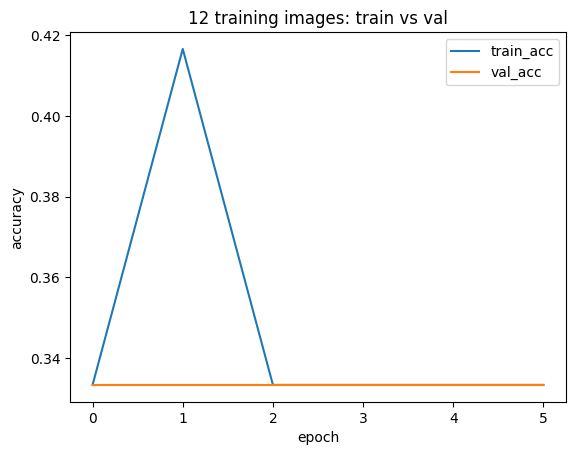

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
실제: [1 0 2]
예측: [0 0 0]
테스트 확률 분포:
[[0.957 0.013 0.03 ]
 [0.693 0.029 0.278]
 [0.547 0.131 0.321]]


In [9]:
plt.plot(hist.history['accuracy'], label='train_acc')
plt.plot(hist.history['val_accuracy'], label='val_acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('12 training images: train vs val')
plt.show()

pred = model.predict(x_te)
print("실제:", np.argmax(y_te, axis=1))
print("예측:", np.argmax(pred, axis=1))
print("테스트 확률 분포:")
print(pred.round(3))


### 2-5. 무슨 일이 일어났는가 ★

실행 결과를 그대로 옮기면:

**학습 로그 (셀 2-3):**
```
Epoch 1: loss 1.07  val_loss 1.95   val_acc 0.3333
Epoch 2: loss 1.56  val_loss 9.41   val_acc 0.3333   ← 손실 폭발 시작
Epoch 3: loss 10.04 val_loss 15.02  val_acc 0.3333
...
Epoch 6: EarlyStopping 종료          val_acc 0.3333
```

**예측 결과 (셀 2-4):**
```
실제:  [1, 0, 2]
예측:  [0, 0, 0]    ← 전부 클래스 0으로 찍음
확률:  [[0.957, 0.013, 0.030],
        [0.693, 0.029, 0.278],
        [0.547, 0.131, 0.321]]
```

세 가지가 동시에 무너졌다:

1. **검증 정확도가 처음부터 끝까지 0.3333에 고정됐다.** 클래스가 3개니까 **0.333은 아무거나 찍기(우연)** 수준이다.
   모델은 **한 번도 우연 이상으로 맞힌 적이 없다.**
2. **손실이 폭발했다.** val_loss가 1.95 → 9.41 → 15.02로 치솟았다.
   12장으로 1,050만 파라미터를 학습하려니 가중치가 통제 불능으로 커진 것이다.
3. **모든 테스트 샘플을 클래스 0(ljh)으로 찍었다.** 실제가 `[1, 0, 2]`인데 예측은 `[0, 0, 0]`.
   우연히 두 번째(0)만 맞아서 1/3 = 0.333이 됐다. **모델은 사실상 "무조건 0"이라고 답하는 것과 다름없다.**

#### 왜 이렇게 됐나

- **데이터가 압도적으로 부족하다.** 학습 12장 vs 파라미터 1,050만 개.
  모델은 12장을 외우는 것조차 버거운 게 아니라, **외울 것 자체가 너무 적어 일반화할 패턴이 없다.**
- **얼굴은 어렵다.** 100×100을 그냥 1차원으로 펼친 DNN은 눈·코·입의 **위치 관계**를 못 본다
  (노트북 01의 flatten 한계). 얼굴 인식은 원래 CNN·전이학습·수천 장 단위 데이터가 필요한 문제다.
- EarlyStopping이 6에폭에서 멈춰 줬지만, **애초에 배울 게 없으니** 멈춰도 결과는 우연 수준이다.

> **교훈: 모델을 키운다고 성능이 오르지 않는다. 데이터가 먼저다.**
> 파라미터 1,050만 개짜리 거대한 모델도, 데이터 12장 앞에서는 동전 던지기만도 못하다.
> (노트북 01의 LFW는 같은 구조로 1,140장을 썼더니 83.5%가 나왔다 — 차이는 오직 데이터 양이다.)

---

## 정리 — 이 노트북의 두 함정

| | 무엇이 문제였나 | 증상 | 교훈 |
|---|---|---|---|
| **1부. 극성 버그** | 추론 데이터가 학습 데이터와 형태가 다름 (밝기 반전) | 확률 **0.99997**로 확신하며 **오답(3)** | softmax 확률 ≠ 신뢰도. 전처리를 학습 때와 똑같이 |
| **2부. 과소 데이터** | 데이터 12장에 파라미터 1,050만 개 | 손실 폭발, val_acc **0.333**(우연), 전부 한 클래스로 | 모델 크기보다 **데이터 양**이 먼저 |

두 실패 모두 **"학습 때 봤던 것"과 "실전에서 마주친 것"의 간극**에서 나왔다.
정확도 숫자 하나만 믿으면 이 간극을 놓친다.

**다음 노트북(03)** 에서는 flatten의 한계 — 위치 정보를 버리는 문제 — 를
**CNN**이 어떻게 해결하는지 본다.